# Notebook 3 — A model that grows its own ITCZ

### And the first real clue to why climate models grow two

Here is the problem we are working towards.

In the observed Pacific, the band of deep convection and heavy rain — the
**Intertropical Convergence Zone** — sits in a *single* band near **6°N**, almost
all year. Nearly every coupled climate model ever built produces a **second,
spurious band near 6°S**. This is the **double-ITCZ bias**. It has survived three
generations of model development (CMIP3 → CMIP5 → CMIP6) largely intact, and it
distorts model projections of tropical rainfall, monsoons and ENSO.

Before we can explain why models get it wrong, we need a reason why the ITCZ is
where it is at all. That reason turns out to be **energetic**, and it is
beautiful: *the rainband sits where the atmosphere's energy transport changes
sign.* Push energy across the equator and the rain follows.

In this notebook you will build a one-dimensional moist energy-balance model,
watch it place its own ITCZ, derive the theory that predicts where, and then
reproduce — in miniature — the mechanism most often blamed for the double-ITCZ
bias in real models.

**New Python:** building a numerical grid, finite differences, flux-conservative
schemes, and running an experiment *ensemble*.

---

> **Setup.** This notebook needs only `numpy`, `scipy` and `matplotlib` — no
> data files, no downloads. If you have already run
> `00_observed_rainfall.ipynb`, use the same kernel and you are ready. If you
> have not set anything up yet, open that notebook and follow the
> *Before you start* section: Codespaces takes about five minutes and installs
> nothing on your laptop.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

C_BLUE, C_ORANGE, C_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
C_YELLOW, C_MAGENTA, C_VIOLET, C_RED = "#eda100", "#e87ba4", "#4a3aa7", "#e34948"
C_INK, C_MUTED, C_GRID = "#0b0b0b", "#898781", "#e1e0d9"

plt.rcParams.update({
    "figure.figsize": (8, 4.6), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": C_INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "text.color": C_INK, "font.size": 10,
    "lines.linewidth": 2.0, "legend.frameon": False,
})
DEG = np.pi / 180
print("Ready.")

Ready.


---
## 1. The right variable: moist static energy

Notebook 1 tracked temperature. In the tropics that is the wrong quantity,
because most of the energy moving around is not heat — it is **water vapour**.
Evaporate a kilogram of water and you have stored 2.5 million joules; condense it
1000 km away and you release them there. The atmosphere is a heat engine that
runs largely on latent heat.

The conserved quantity that accounts for this is **moist static energy**
(per kilogram of air):

$$h \;=\; \underbrace{c_p T}_{\text{sensible}} \;+\; \underbrace{L_v q}_{\text{latent}} \;+\; \underbrace{gz}_{\text{potential}}$$

We work with near-surface air and drop $gz$. The specific humidity $q$ is set by
temperature through the **Clausius–Clapeyron** relation, which says saturation
vapour pressure rises *exponentially* with temperature:

$$e_s(T) = 610.94\,\exp\!\left(\frac{17.625\,T}{T + 243.04}\right)\ \text{Pa}, \qquad
  q = \mathrm{RH}\,\frac{0.622\,e_s}{p_0}$$

roughly 7% more water vapour per kelvin of warming. This exponential is the
single most consequential curve in tropical meteorology.

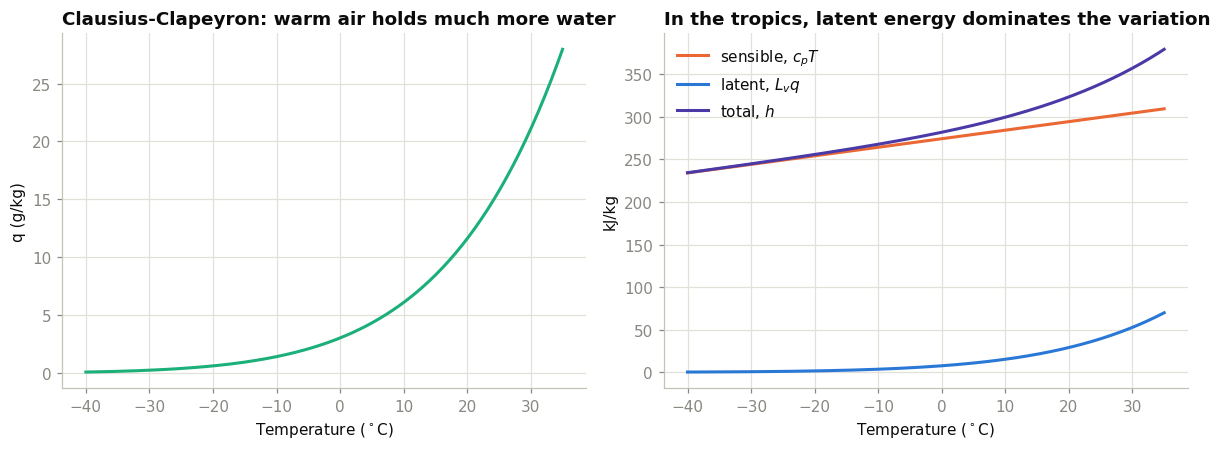

In [2]:
cp, Lv, p0, RH = 1004.0, 2.5e6, 1.0e5, 0.80


def sat_vapour_pressure(T_C):
    """Saturation vapour pressure, Pa. T in Celsius."""
    return 610.94 * np.exp(17.625 * T_C / (T_C + 243.04))


def specific_humidity(T_C, rh=RH):
    """Specific humidity, kg/kg."""
    return rh * 0.622 * sat_vapour_pressure(T_C) / p0


def moist_static_energy(T_C, rh=RH):
    """Moist static energy, J/kg."""
    return cp * (T_C + 273.15) + Lv * specific_humidity(T_C, rh)


Tc = np.linspace(-40, 35, 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(Tc, 1000 * specific_humidity(Tc), color=C_AQUA)
ax1.set_xlabel("Temperature ($^\\circ$C)"); ax1.set_ylabel("q (g/kg)")
ax1.set_title("Clausius-Clapeyron: warm air holds much more water")

ax2.plot(Tc, cp * (Tc + 273.15) / 1000, color=C_ORANGE, label="sensible, $c_pT$")
ax2.plot(Tc, Lv * specific_humidity(Tc) / 1000, color=C_BLUE, label="latent, $L_vq$")
ax2.plot(Tc, moist_static_energy(Tc) / 1000, color=C_VIOLET, label="total, $h$")
ax2.set_xlabel("Temperature ($^\\circ$C)"); ax2.set_ylabel("kJ/kg")
ax2.set_title("In the tropics, latent energy dominates the variation")
ax2.legend(loc="upper left")
plt.tight_layout(); plt.show()

Look at the right panel. Between $-40^\circ$C and $+35^\circ$C the sensible term
rises by about 75 kJ/kg while the latent term rises by nearly 70 kJ/kg — from
essentially nothing. **Almost all of the tropics-to-pole contrast in $h$ comes
from water vapour**, and $h$ is far more sharply peaked at the equator than
temperature is. Remember that: it is why the ITCZ is narrow.

---
## 2. The model

One dimension, latitude only, annual mean. At each latitude the atmospheric
column gains and loses energy:

$$C\,\frac{\partial T}{\partial t} \;=\;
  \underbrace{S(\phi)\,(1-\alpha)}_{\text{absorbed solar}}
  \;-\;\underbrace{(A + B\,T)}_{\text{emitted to space}}
  \;-\;\underbrace{\nabla\!\cdot\!\mathbf{F}}_{\text{energy exported}}
  \;+\;\underbrace{R(\phi)}_{\text{our forcing}}$$

Three modelling choices, each worth understanding:

**1. Linear longwave.** $\text{OLR} = A + BT$ with $B = 1.7\ \mathrm{W\,m^{-2}\,K^{-1}}$
($T$ in °C). This is an empirical fit to satellite data — a linearisation of
Notebook 1's $\varepsilon\sigma T^4$ that also absorbs the water-vapour and
lapse-rate feedbacks. We pick $A$ so the model's global mean lands on the
observed 14°C, rather than pulling a number from the air.

The albedo is no longer uniform either: it rises from about 0.24 at the equator
to about 0.51 at the poles, because of ice, snow, and sunlight striking the sea
surface at a glancing angle. (This is Notebook 1's ice–albedo effect, prescribed
instead of interactive. Without it the poles come out far too warm and the model
transports only half the energy it should — try it, in Exercise 7.)

**2. Transport as diffusion.** The real atmosphere moves energy with the Hadley
cell and with midlatitude eddies. We model the whole business as **downgradient
diffusion of moist static energy**. The vertically integrated northward energy
flux, per metre of latitude circle, is

$$F \;=\; -\,\frac{p_s}{g}\,\nu\;\frac{1}{a}\frac{\partial h}{\partial\phi}
  \qquad [\mathrm{W\,m^{-1}}]$$

Two physically meaningful constants, not one fudge factor:

- $p_s/g \approx 1.02\times10^{4}\ \mathrm{kg\,m^{-2}}$ is the **mass of the
  atmosphere above each square metre** — weigh the air by its own surface
  pressure.
- $\nu \approx 1.2\times10^{6}\ \mathrm{m^{2}\,s^{-1}}$ is a **macroturbulent
  diffusivity**: how vigorously eddies stir. This is our one tuned parameter
  (Exercise 2 asks you to tune it yourself).

Check the units, always: $\mathrm{kg\,m^{-2}} \times \mathrm{m^{2}\,s^{-1}}
\times \mathrm{J\,kg^{-1}\,m^{-1}} = \mathrm{J\,s^{-1}\,m^{-1}} = \mathrm{W\,m^{-1}}$.
Multiply by the circumference $2\pi a\cos\phi$ and you get watts — the number
that should come out near 5 PW.

Crude, but it captures the essential fact: **energy flows from high $h$ to low
$h$.** Note where this immediately leads —

> $$F = 0 \iff \frac{\partial h}{\partial\phi} = 0$$
>
> **The energy flux vanishes exactly at the maximum of moist static energy.**

Hold on to that. It is the whole notebook in one line.

**3. Spherical geometry.** On a sphere the divergence of a meridional flux is

$$\nabla\cdot\mathbf{F} = \frac{1}{a\cos\phi}\frac{\partial}{\partial\phi}\big(F\cos\phi\big)
  \qquad [\mathrm{W\,m^{-2}}]$$

The $\cos\phi$ appears because latitude circles shrink towards the poles — the
same energy flux squeezed into a shorter circle means stronger convergence.
We enforce it exactly by evaluating fluxes on the **edges** between grid cells
and differencing them — a *flux-conservative* scheme, which guarantees that
energy leaving one cell arrives in its neighbour and none is created from nothing.

In [3]:
# ---------------- grid ----------------
N = 120                                        # number of cells: 1.5 degrees each
lat_edges = np.linspace(-90, 90, N + 1)        # cell boundaries
lat = 0.5 * (lat_edges[1:] + lat_edges[:-1])   # cell centres
dphi = (lat[1] - lat[0]) * DEG                 # grid spacing in radians
cos_c, cos_e = np.cos(lat * DEG), np.cos(lat_edges * DEG)

# ---------------- constants ----------------
a_earth = 6.371e6           # m
S_solar = 1361.0
B_olr   = 1.7               # W m-2 K-1, longwave sensitivity
PS_OVER_G = 1.02e4          # kg m-2, mass of atmosphere per unit area
NU      = 1.2e6             # m2 s-1, macroturbulent diffusivity (the tuned knob)
C_heat  = 1.0e7             # J m-2 K-1 (a shallow slab, for fast spin-up)


def annual_mean_insolation(lat_deg, obliquity=23.44):
    """Annual mean TOA insolation (circular orbit), reusing Notebook 2's formula."""
    days = np.arange(1, 366)
    phi = np.asarray(lat_deg)[:, None] * DEG
    lam = 2 * np.pi * (days[None, :] - 80) / 365.25
    dec = np.arcsin(np.sin(obliquity * DEG) * np.sin(lam))
    h0 = np.arccos(np.clip(-np.tan(phi) * np.tan(dec), -1, 1))
    Q = (S_solar / np.pi) * (h0 * np.sin(phi) * np.sin(dec)
                             + np.cos(phi) * np.cos(dec) * np.sin(h0))
    return Q.mean(axis=1)


# Albedo rises towards the poles: ice, snow, and sunlight arriving at a glancing
# angle off the sea surface. P2 is the second Legendre polynomial, the standard
# shape for this (it has zero global mean, so a0 IS the planetary albedo).
def legendre_P2(x):
    return 0.5 * (3 * x**2 - 1)


albedo = 0.33 + 0.18 * legendre_P2(np.sin(lat * DEG))
S_in = annual_mean_insolation(lat)
ASR = S_in * (1 - albedo)

# Choose A so the model's global mean temperature comes out at the observed 14 C.
A_olr = np.sum(ASR * cos_c) / np.sum(cos_c) - B_olr * 14.0
D_diff = PS_OVER_G * NU

print(f"Grid: {N} cells of {lat[1]-lat[0]:.1f} deg")
print(f"Albedo: {albedo.min():.2f} at the equator, {albedo.max():.2f} at the pole")
print(f"Global mean ASR: {np.sum(ASR*cos_c)/np.sum(cos_c):.1f} W m-2")
print(f"Longwave law: OLR = {A_olr:.1f} + {B_olr} * T   (T in Celsius)")

Grid: 120 cells of 1.5 deg
Albedo: 0.24 at the equator, 0.51 at the pole
Global mean ASR: 233.8 W m-2
Longwave law: OLR = 210.0 + 1.7 * T   (T in Celsius)


### The solver

Same forward-Euler idea as Notebook 1, now applied at 180 latitudes at once. The
only new piece is the transport term. Read it in three steps:

1. compute $h$ at cell centres,
2. compute the flux $F$ on the edges from the difference of neighbouring $h$,
   setting $F=0$ at both poles (nothing flows out of the top of the world),
3. the convergence in each cell is the difference of the edge fluxes, weighted by
   $\cos\phi$.

In [4]:
def run_model(forcing=None, n_steps=30000, dt=1200.0, T_init=None):
    """
    Integrate the moist EBM to equilibrium.

    forcing : extra energy input in W m-2 at each latitude (e.g. a cloud bias)
    returns : dict with the equilibrium state and diagnostics

    dt is capped by numerical stability: an explicit diffusion scheme blows up
    if dt exceeds roughly C / (2k), where k is the diffusive coupling between
    neighbouring cells. Try dt = 4000 below and watch it explode -- knowing what
    instability looks like is worth five minutes of your life.
    """
    R = np.zeros(N) if forcing is None else np.asarray(forcing, dtype=float)
    T = np.full(N, 15.0) if T_init is None else T_init.copy()

    for _ in range(n_steps):
        h = moist_static_energy(T)                        # J/kg at cell centres

        F = np.zeros(N + 1)                               # W m-1 on cell edges
        F[1:-1] = -(D_diff / a_earth) * np.diff(h) / dphi # zero at both poles

        conv = -(1.0 / (a_earth * cos_c)) * np.diff(F * cos_e) / dphi
        T = T + dt / C_heat * (ASR - (A_olr + B_olr * T) + conv + R)

    # --- diagnostics ---
    h = moist_static_energy(T)
    F = np.zeros(N + 1)
    F[1:-1] = -(D_diff / a_earth) * np.diff(h) / dphi
    F_total = 2 * np.pi * a_earth * cos_e * F             # watts across each circle
    NEI = ASR - (A_olr + B_olr * T) + R                   # net energy into the column

    return dict(T=T, h=h, F=F, F_total=F_total, NEI=NEI, R=R)


def energy_flux_equator(F_total, lat_edges=lat_edges, window=60.0):
    """
    Latitude where the northward energy transport crosses zero from
    negative to positive -- i.e. where energy DIVERGES. That is the ITCZ.
    """
    inside = np.abs(lat_edges) < window
    idx = np.where(inside[:-1] & inside[1:]
                   & (F_total[:-1] < 0) & (F_total[1:] >= 0))[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    f0, f1 = F_total[i], F_total[i + 1]
    return lat_edges[i] + (lat_edges[i + 1] - lat_edges[i]) * (-f0) / (f1 - f0)


ctrl = run_model()
print(f"Control run: ITCZ (energy flux equator) at {energy_flux_equator(ctrl['F_total']):+.2f} deg")
print(f"Peak northward transport: {ctrl['F_total'].max()/1e15:.2f} PW "
      f"at {lat_edges[ctrl['F_total'].argmax()]:.0f} deg N")
print(f"Equatorial temperature: {ctrl['T'][N//2]:.1f} C,  polar: {ctrl['T'][0]:.1f} C")

Control run: ITCZ (energy flux equator) at +0.02 deg
Peak northward transport: 5.58 PW at 33 deg N
Equatorial temperature: 26.9 C,  polar: -20.6 C


Those numbers are worth pausing on. Roughly 27°C at the equator, about $-21$°C at
the pole, 5.6 PW of peak poleward transport at 33°N — against observed values of
about 26°C, $-20$°C, and 5.5 PW near 35°N. All of it emerging from orbital
geometry, a linear longwave law, a prescribed albedo and **one** tuned number.
No winds, no clouds, no ocean, no computer larger than your laptop.

Let's look at the state.

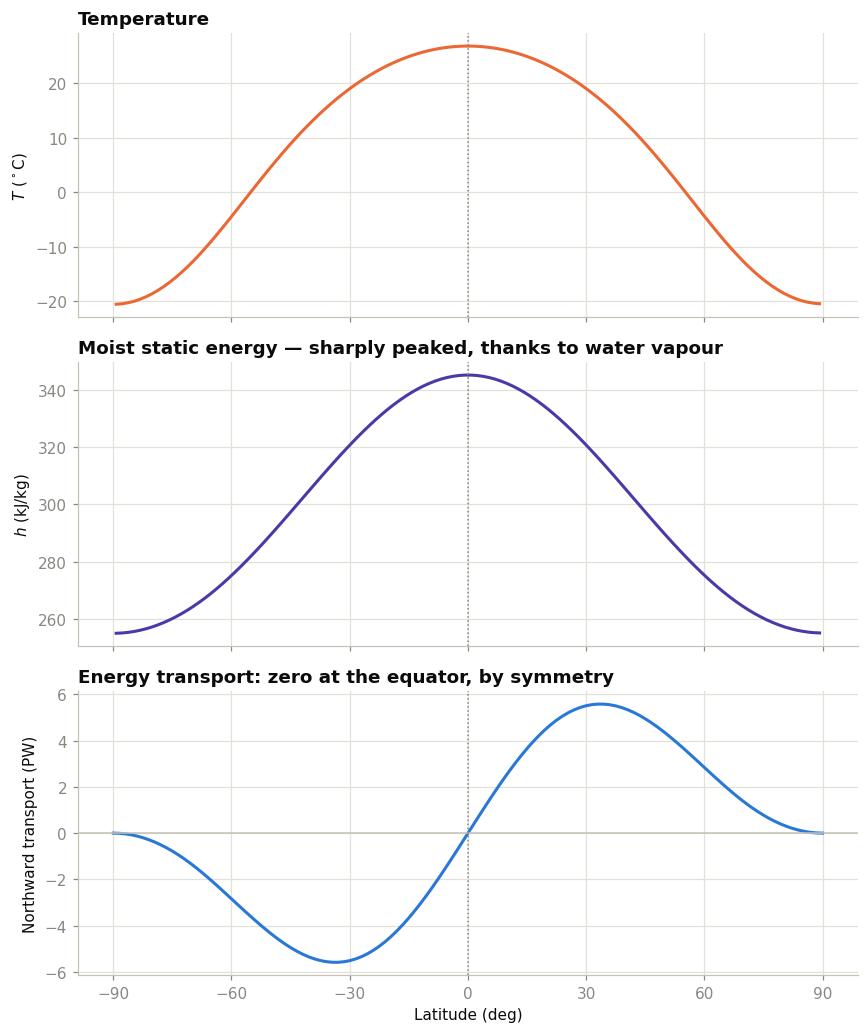

In [5]:
res = ctrl
fig, axes = plt.subplots(3, 1, figsize=(8, 9.5), sharex=True)

axes[0].plot(lat, res["T"], color=C_ORANGE)
axes[0].set_ylabel("$T$ ($^\\circ$C)"); axes[0].set_title("Temperature")

axes[1].plot(lat, res["h"] / 1000, color=C_VIOLET)
axes[1].set_ylabel("$h$ (kJ/kg)"); axes[1].set_title("Moist static energy — sharply peaked, thanks to water vapour")

axes[2].plot(lat_edges, res["F_total"] / 1e15, color=C_BLUE)
axes[2].axhline(0, color="#c3c2b7", lw=1)
axes[2].set_ylabel("Northward transport (PW)")
axes[2].set_xlabel("Latitude (deg)")
axes[2].set_title("Energy transport: zero at the equator, by symmetry")

for ax in axes:
    ax.axvline(0, color=C_MUTED, ls=":", lw=1)
axes[0].set_xticks(np.arange(-90, 91, 30))
plt.tight_layout(); plt.show()

A perfectly symmetric planet puts its ITCZ exactly on the equator. Of course it
does — nothing in the model knows north from south.

**The real Earth is not symmetric.** Its ITCZ sits several degrees north. To
understand why, and to understand how a model could get it wrong, we need to
break the symmetry.

---
## 3. The theory: why the ITCZ tracks the energy flux equator

Before running experiments, let's predict the answer.

Call $F(\phi)$ the northward energy flux per unit length. Its divergence is the
net energy input to the column, $\text{NEI} = \text{ASR} - \text{OLR} + R$:

$$\frac{\partial F}{\partial y} = \mathrm{NEI}(\phi), \qquad y = a\phi$$

Now suppose the flux vanishes at some latitude $y_0$ — the **energy flux
equator**. Taylor expand $F$ about the equator:

$$F(y) \approx F(0) + \left.\frac{\partial F}{\partial y}\right|_0 y
       = F(0) + \mathrm{NEI}(0)\,y$$

Set that to zero:

$$\boxed{\;\phi_{\mathrm{EFE}} \;\approx\; -\,\frac{F(0)}{a\;\mathrm{NEI}(0)}\;}$$

Read it out loud: **the ITCZ sits opposite the direction of cross-equatorial
energy transport.** If the atmosphere carries energy *southward* across the
equator ($F(0)<0$), the ITCZ is displaced *north*. The stronger the transport,
the bigger the shift; the denominator $\mathrm{NEI}(0)$ — how strongly the
equatorial column is gaining energy — sets the stiffness.

This is the **Bischoff–Schneider relation** (2014), and it is the workhorse of
the modern literature on ITCZ shifts. You now have a model to test it in.

> **Why does the rain go where the flux vanishes?** In the deep tropics the
> Hadley circulation carries energy in the direction its *upper* branch flows,
> and mass in the direction its *lower* branch flows — opposite directions. Air
> converges and rises at the dividing latitude, and rising air rains. So the
> energy-flux zero and the mass convergence coincide: the ITCZ.

---
## 4. Breaking the symmetry

Add a patch of extra energy input at some latitude — a Gaussian bump — and see
what the ITCZ does. We subtract the patch's global mean so the *global* budget is
untouched: this experiment **moves energy around, it does not add any**. Any
response is a redistribution, not a warming.

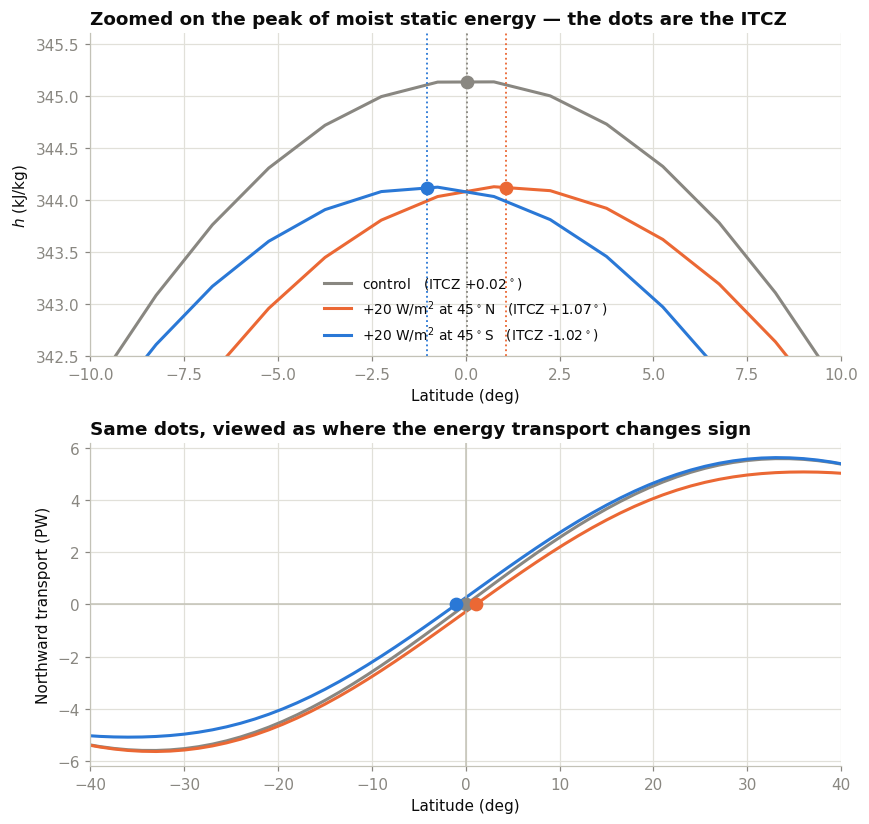

In [6]:
def gaussian_patch(centre_deg, amplitude, width_deg=12.0):
    """A localised energy-input anomaly with zero global mean, W m-2."""
    R = amplitude * np.exp(-((lat - centre_deg) / width_deg) ** 2)
    return R - np.sum(R * cos_c) / np.sum(cos_c)          # remove the global mean


runs = {
    "control":                 run_model(),
    "+20 W/m$^2$ at 45$^\\circ$N": run_model(gaussian_patch(45, 20)),
    "+20 W/m$^2$ at 45$^\\circ$S": run_model(gaussian_patch(-45, 20)),
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7.6))

for (name, r), col in zip(runs.items(), [C_MUTED, C_ORANGE, C_BLUE]):
    phi = energy_flux_equator(r["F_total"])
    # zoom in hard on the top panel: these shifts are about a degree
    ax1.plot(lat, r["h"] / 1000, color=col,
             label=f"{name}   (ITCZ {phi:+.2f}$^\\circ$)")
    ax1.axvline(phi, color=col, ls=":", lw=1.2)
    ax1.plot([phi], [np.interp(phi, lat, r["h"]) / 1000], "o", ms=8, color=col, zorder=5)
    ax2.plot(lat_edges, r["F_total"] / 1e15, color=col)
    ax2.plot([phi], [0], "o", ms=8, color=col, zorder=5)

ax1.set_xlim(-10, 10); ax1.set_ylim(342.5, 345.6)
ax1.set_xlabel("Latitude (deg)"); ax1.set_ylabel("$h$ (kJ/kg)")
ax1.set_title("Zoomed on the peak of moist static energy — the dots are the ITCZ")
ax1.legend(loc="lower center", fontsize=9)

ax2.axhline(0, color="#c3c2b7", lw=1); ax2.axvline(0, color="#c3c2b7", lw=1)
ax2.set_xlim(-40, 40); ax2.set_xticks(np.arange(-40, 41, 10))
ax2.set_ylabel("Northward transport (PW)"); ax2.set_xlabel("Latitude (deg)")
ax2.set_title("Same dots, viewed as where the energy transport changes sign")
plt.tight_layout(); plt.show()

**Heat the northern extratropics and the tropical rainband moves north.** The
forcing is 45 degrees away from the equator and the ITCZ feels it anyway — because
the anomaly has to be exported, and exporting it means driving an energy flux
across the equator, and that displaces the latitude where the flux vanishes.

This is the single most important idea in modern ITCZ theory, and it is why
things as remote as **Arctic sea ice, Saharan dust, European aerosol pollution
and the Atlantic overturning circulation** all show up in the literature as
controls on tropical rainfall.

---
## 5. Testing the theory quantitatively

Now the real test. Run an *ensemble*: sweep the forcing amplitude from strongly
negative to strongly positive, and for each run record both the diagnosed ITCZ
latitude and the cross-equatorial energy transport. Then compare against the
Bischoff–Schneider prediction.

Predicting one number is a coincidence. Predicting a whole curve is a theory.

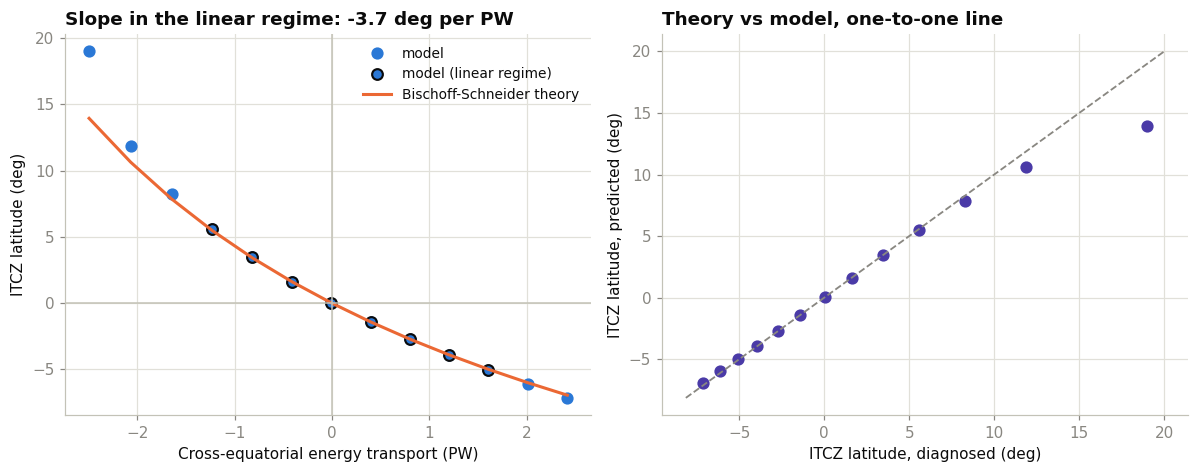

Sensitivity: -3.71 degrees of ITCZ shift per PW of cross-equatorial transport
Published estimates from GCMs and observations: roughly 3 deg/PW.


In [7]:
amplitudes = np.arange(-180, 181, 30.0)     # deliberately pushed far beyond realism
itcz_lat, F_cross, predicted = [], [], []

for amp in amplitudes:
    r = run_model(gaussian_patch(45, amp))
    itcz_lat.append(energy_flux_equator(r["F_total"]))

    i_eq = N // 2                                   # index of the equator
    F_eq = r["F_total"][i_eq] / (2 * np.pi * a_earth)   # back to W m-2
    NEI_eq = r["NEI"][i_eq]
    F_cross.append(r["F_total"][i_eq] / 1e15)           # PW, for plotting
    predicted.append(-F_eq / (a_earth * NEI_eq) / DEG)  # the boxed formula

itcz_lat, F_cross, predicted = map(np.array, (itcz_lat, F_cross, predicted))

# Fit the slope only where the theory is meant to apply: small shifts.
linear = np.abs(itcz_lat) < 6.0
slope = np.polyfit(F_cross[linear], itcz_lat[linear], 1)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

ax1.plot(F_cross, itcz_lat, "o", ms=7, color=C_BLUE, label="model")
ax1.plot(F_cross[linear], itcz_lat[linear], "o", ms=7, color=C_BLUE,
         mec=C_INK, mew=1.4, label="model (linear regime)")
ax1.plot(F_cross, predicted, color=C_ORANGE, label="Bischoff-Schneider theory")
ax1.axhline(0, color="#c3c2b7", lw=1); ax1.axvline(0, color="#c3c2b7", lw=1)
ax1.set_xlabel("Cross-equatorial energy transport (PW)")
ax1.set_ylabel("ITCZ latitude (deg)")
ax1.set_title(f"Slope in the linear regime: {slope:.1f} deg per PW")
ax1.legend(loc="upper right", fontsize=9)

ax2.plot(itcz_lat, predicted, "o", ms=7, color=C_VIOLET)
lims = [min(itcz_lat.min(), predicted.min()) - 1, max(itcz_lat.max(), predicted.max()) + 1]
ax2.plot(lims, lims, color=C_MUTED, ls="--", lw=1.2)
ax2.set_xlabel("ITCZ latitude, diagnosed (deg)")
ax2.set_ylabel("ITCZ latitude, predicted (deg)")
ax2.set_title("Theory vs model, one-to-one line")
plt.tight_layout(); plt.show()

print(f"Sensitivity: {slope:.2f} degrees of ITCZ shift per PW of cross-equatorial transport")
print("Published estimates from GCMs and observations: roughly 3 deg/PW.")

Two things happened here, and both matter.

**Near the equator the theory is not approximately right — it is essentially
exact.** For shifts up to about 5° the predicted and diagnosed latitudes agree to
better than a tenth of a degree. That is what a good theory looks like.

**Far from the equator it fails, and it fails in a specific direction.** Beyond
roughly 8° the model's ITCZ runs away from the prediction. This is the Taylor
expansion giving up: we linearised $F$ about the equator, assuming the ITCZ stays
nearby, and once the energy flux equator wanders into latitudes where
$\mathrm{NEI}$ is changing, the single-term expansion loses the plot.

Knowing *where* your approximation breaks is as valuable as the approximation.
When you read papers applying this relation to real GCMs, check whether the
shifts they discuss are inside the linear regime. Usually they are — which is
precisely why the framework has been so productive.

---
## 6. The double-ITCZ connection

Now we can state the leading hypothesis about the bias.

Coupled climate models have a well-documented, decades-old problem over the
**Southern Ocean**: they simulate too few and too thin low clouds, so too much
sunlight is absorbed there. The bias in CMIP models has historically reached
**20–30 W m⁻²** in the zonal mean around 45–60°S. (It shrank in CMIP6 but did not
vanish.)

Follow the energetics. Extra energy absorbed in the Southern Hemisphere must be
exported. Exporting it drives an anomalous *northward* cross-equatorial flux. By
the boxed formula, a northward $F(0)$ pushes the ITCZ **south** — towards the
equator and past it, feeding a southern rainband that should not be there.

Let's do that experiment.

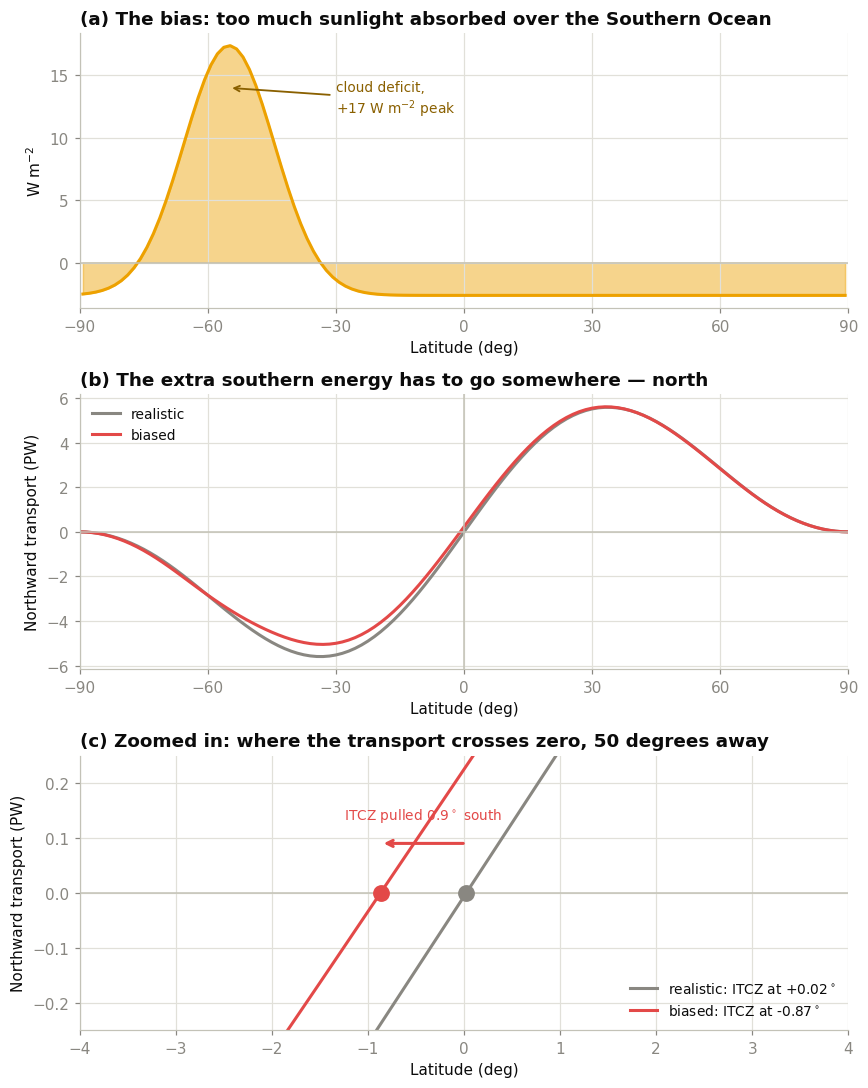

Southern Ocean bias shifted the ITCZ by -0.89 degrees
Change in cross-equatorial energy transport: +0.231 PW (positive = northward)


In [8]:
so_bias = gaussian_patch(-55, 20, width_deg=15)     # too-bright Southern Ocean
biased = run_model(so_bias)

phi_c = energy_flux_equator(ctrl["F_total"])
phi_b = energy_flux_equator(biased["F_total"])
dF = (biased["F_total"][N // 2] - ctrl["F_total"][N // 2]) / 1e15

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))

# --- (a) the forcing, over the whole globe ---
ax1.fill_between(lat, 0, so_bias, color=C_YELLOW, alpha=0.45)
ax1.plot(lat, so_bias, color=C_YELLOW)
ax1.axhline(0, color="#c3c2b7", lw=1)
ax1.set_xlim(-90, 90); ax1.set_xticks(np.arange(-90, 91, 30))
ax1.set_ylabel("W m$^{-2}$"); ax1.set_xlabel("Latitude (deg)")
ax1.set_title("(a) The bias: too much sunlight absorbed over the Southern Ocean")
ax1.annotate("cloud deficit,\n$+17$ W m$^{-2}$ peak", xy=(-55, 14), xytext=(-30, 12),
             color="#8a6000", fontsize=9,
             arrowprops=dict(arrowstyle="->", color="#8a6000", lw=1.2))

# --- (b) the energy transport response, whole globe ---
ax2.plot(lat_edges, ctrl["F_total"] / 1e15, color=C_MUTED, label="realistic")
ax2.plot(lat_edges, biased["F_total"] / 1e15, color=C_RED, label="biased")
ax2.axhline(0, color="#c3c2b7", lw=1); ax2.axvline(0, color="#c3c2b7", lw=1)
ax2.set_xlim(-90, 90); ax2.set_xticks(np.arange(-90, 91, 30))
ax2.set_ylabel("Northward transport (PW)"); ax2.set_xlabel("Latitude (deg)")
ax2.set_title("(b) The extra southern energy has to go somewhere — north")
ax2.legend(loc="upper left", fontsize=9)

# --- (c) zoom on the equator: the ITCZ moves ---
ax3.plot(lat_edges, ctrl["F_total"] / 1e15, color=C_MUTED, label=f"realistic: ITCZ at {phi_c:+.2f}$^\\circ$")
ax3.plot(lat_edges, biased["F_total"] / 1e15, color=C_RED, label=f"biased: ITCZ at {phi_b:+.2f}$^\\circ$")
ax3.axhline(0, color="#c3c2b7", lw=1)
ax3.plot([phi_c], [0], "o", ms=10, color=C_MUTED, zorder=5)
ax3.plot([phi_b], [0], "o", ms=10, color=C_RED, zorder=5)
ax3.annotate("", xy=(phi_b, 0.09), xytext=(phi_c, 0.09),
             arrowprops=dict(arrowstyle="->", color=C_RED, lw=2))
ax3.text(0.5 * (phi_b + phi_c), 0.135, f"ITCZ pulled {phi_c - phi_b:.1f}$^\\circ$ south",
         color=C_RED, ha="center", fontsize=9)
ax3.set_xlim(-4, 4); ax3.set_ylim(-0.25, 0.25)
ax3.set_xlabel("Latitude (deg)"); ax3.set_ylabel("Northward transport (PW)")
ax3.set_title("(c) Zoomed in: where the transport crosses zero, 50 degrees away")
ax3.legend(loc="lower right", fontsize=9)

plt.tight_layout(); plt.show()

print(f"Southern Ocean bias shifted the ITCZ by {phi_b - phi_c:+.2f} degrees")
print(f"Change in cross-equatorial energy transport: {dF:+.3f} PW (positive = northward)")

### What this does and does not explain

**Does:** the *direction*, and a defensible *magnitude*. A Southern Ocean
radiation bias of the size real models have carried drives a few tenths of a
petawatt of spurious northward cross-equatorial transport and pulls the rainband
about a degree south. That is the right order for what the literature attributes
to this mechanism — a real contribution, not the whole bias. You just reproduced
its skeleton in about eighty lines of Python.

**A caution you should carry into the literature.** Apply the same formula to the
real atmosphere — observed cross-equatorial transport is roughly 0.2 PW southward
— and you predict an ITCZ near 1°N. The observed Pacific ITCZ is near 6°N. The
energetic framework is excellent at predicting *shifts* and much weaker at
predicting *absolute position*, because the precipitation maximum and the energy
flux equator are related but not identical, and because the real tropics have
land, an ocean circulation, and a cold tongue. Be precise about which claim you
are making.

**Does not:** produce *two* rainbands. Our model has exactly one energy flux
equator, by construction — a single smooth $h$ curve has a single maximum. It has
no ocean, no sea-surface temperature pattern, no equatorial cold tongue, no
convective threshold, no clouds that respond to anything.

The real double-ITCZ bias needs those. The other half of the story is oceanic:
models make the equatorial Pacific **cold tongue** too strong and extend it too
far west, while making the southeastern Pacific **too warm** (their
stratocumulus decks are too thin). Deep convection switches on above a threshold
SST of roughly 27°C, so a too-warm southeast Pacific lights up a rainband that
should not exist, and a too-cold equator suppresses the one that should.

Energetics sets *where the tropical rainbelt wants to be*; SST patterns and
convective thresholds decide *whether it splits in two*. A full account needs
both — which is exactly why this bias has proved so stubborn.

---
## 7. Where we are, and what comes next

You have built: a global energy balance model with multiple equilibria, the
orbital geometry of insolation, and a moist diffusive model that predicts the
latitude of the tropical rainband and responds correctly to remote forcing. You
have tested a published theory against your own model and found where it breaks.

The next step is to stop trusting models and go look. Notebooks 4–6:

**4. The observed ITCZ.** Satellite precipitation (GPCP or IMERG) and observed
SST. Make the annual-mean precipitation map, the seasonal migration Hovmöller,
and the precipitation-versus-SST scatter that reveals the convective threshold.
Define the **precipitation centroid**, the standard metric:
$$\phi_{\mathrm{cent}} = \frac{\int_{-20^\circ}^{20^\circ}\phi\,P\,\mathrm{d}\phi}{\int_{-20^\circ}^{20^\circ}P\,\mathrm{d}\phi}$$

**5. Meet the models.** CMIP6 historical precipitation for a handful of models.
Plot the meridional profile of eastern-Pacific rainfall for each against
observations — the two-humped signature against the one-humped truth. Rank them
with a double-ITCZ index.

**6. Explain the spread.** Across the ensemble, scatter the double-ITCZ index
against cross-equatorial energy transport, against Southern Ocean absorbed
shortwave, against cold-tongue SST bias. Which one actually predicts the bias?
That is a real, open, publishable question — and by then you will have every tool
you need to attack it.

---
## Exercises

**0. Break it on purpose.** Re-run the control with `dt = 4000`. Plot the result.
You should get garbage — oscillating, exploding temperatures. That is numerical
instability, and every modeller meets it. Then work out roughly where the
threshold sits by bisection, and check it against $\Delta t < C/(2k)$ with
$k = (p_s/g)\,\nu\,(\mathrm{d}h/\mathrm{d}T)/(a\Delta\phi)^2$.

**1. Dry vs moist.** Set `RH = 0.0` (a dry atmosphere) and re-run the control. How
do the equator-to-pole temperature contrast and the peak transport change? Explain
using the right panel of §1. Why does removing water vapour make the temperature
gradient *larger*?

**2. Tuning $\nu$.** The diffusivity is the one free parameter. Run the control
for $\nu$ between $0.5\times10^6$ and $2\times10^6\ \mathrm{m^2\,s^{-1}}$ and plot
both the peak poleward transport and the equator-to-pole temperature difference
against $\nu$. Which value best matches the observed 5.5 PW *and* the observed
~47°C contrast — and can one value do both? Now repeat the §5 sensitivity
experiment at two different $\nu$ — does the degrees-per-petawatt slope depend on
it? Should it, according to the boxed formula?

**3. Where does the forcing matter most?** Fix the amplitude at 20 W m⁻² and move
the patch centre from 80°S to 80°N in steps of 10°. Plot ITCZ shift against patch
latitude. Is a forcing near the equator more or less effective than one at the
pole, per watt? (This is the "efficiency" question in the real literature —
compare your answer to what you would have guessed.)

**4. The ocean's contribution.** The Atlantic overturning circulation carries
roughly 0.4 PW of heat *northward* across the equator, which the atmosphere must
return southward. Represent it: build a forcing that removes energy from the
southern tropics and adds it to the northern tropics with the right total. Where
does the ITCZ end up? Compare with the observed ~6°N.

**5. Break the linearity.** Replace the linear OLR with Notebook 1's
$\varepsilon\sigma T^4$. Does the §5 relation survive? What changes, and why?

**6. Hunt for a second ITCZ.** Can you *force* this model to produce two maxima in
$h$? Try a strongly double-peaked forcing near the equator. What does it take, and
does the result look anything like a real double ITCZ? Argue from your answer why
a diffusive energy-balance model is structurally the wrong tool for this
particular bias — and what the minimum extra ingredient would be.

**7. Why the albedo matters.** Set the albedo back to a uniform 0.30 (delete the
`legendre_P2` term), recompute `A_olr`, and re-run. What happens to the polar
temperature and to the peak transport, and why? This is the experiment that
convinced me to put a latitude-dependent albedo in the model at all — repeat it
and form your own opinion.